In [1]:
import os, glob, time, random, json
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GT_DIR  = "data/train/train/GT"
DEG_DIR = "data/train/train/NoisyLR"

PATCH_SIZE = 96
BATCH_SIZE = 16
EPOCHS     = 30
LR         = 1e-3
SEED       = 42
CHECKPOINT_EVERY = 5   # save weights every N epochs, so any metric can be recomputed later

os.makedirs("checkpoints", exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Using device: cuda


In [2]:
class RestorationDataset(Dataset):
    def __init__(self, gt_dir, deg_dir, patch_size=96, train=True):
        self.gt_paths = sorted(glob.glob(os.path.join(gt_dir, "*.npy")))
        self.deg_dir = deg_dir
        self.patch_size = patch_size
        self.train = train

    def __len__(self):
        return len(self.gt_paths)

    def _load(self, path):
        arr = np.load(path).astype(np.float32)
        if arr.ndim == 3:
            arr = arr.squeeze()
        return arr

    def __getitem__(self, idx):
        gt_path = self.gt_paths[idx]
        fname = os.path.basename(gt_path)
        deg_path = os.path.join(self.deg_dir, fname)

        gt  = self._load(gt_path)
        deg = self._load(deg_path)

        deg_t = torch.from_numpy(deg).float().unsqueeze(0).unsqueeze(0)
        deg_up = F.interpolate(
            deg_t, size=gt.shape, mode="bicubic", align_corners=False
        ).squeeze(0).squeeze(0).numpy()

        gt_n, deg_n = gt, deg_up

        if self.train:
            gt_n, deg_n = self._random_crop_and_augment(gt_n, deg_n)

        gt_out  = torch.from_numpy(gt_n.copy()).unsqueeze(0).float()
        deg_out = torch.from_numpy(deg_n.copy()).unsqueeze(0).float()
        return deg_out, gt_out

    def _random_crop_and_augment(self, gt, deg):
        h, w = gt.shape
        p = self.patch_size
        if h > p and w > p:
            top = random.randint(0, h - p)
            left = random.randint(0, w - p)
            gt  = gt[top:top+p, left:left+p]
            deg = deg[top:top+p, left:left+p]
        if random.random() < 0.5:
            gt, deg = np.fliplr(gt).copy(), np.fliplr(deg).copy()
        if random.random() < 0.5:
            gt, deg = np.flipud(gt).copy(), np.flipud(deg).copy()
        k = random.randint(0, 3)
        gt, deg = np.rot90(gt, k).copy(), np.rot90(deg, k).copy()
        return gt, deg


full_dataset = RestorationDataset(GT_DIR, DEG_DIR, patch_size=PATCH_SIZE, train=True)
n_val = max(1, int(0.1 * len(full_dataset)))
n_train = len(full_dataset) - n_val
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train pairs: {n_train} | Val pairs: {n_val}")

Train pairs: 2880 | Val pairs: 320


In [3]:
class DnCNN(nn.Module):
    def __init__(self, channels=1, num_layers=17, features=64):
        super().__init__()
        layers = [nn.Conv2d(channels, features, 3, padding=1), nn.ReLU(inplace=True)]
        for _ in range(num_layers - 2):
            layers += [
                nn.Conv2d(features, features, 3, padding=1, bias=False),
                nn.BatchNorm2d(features),
                nn.ReLU(inplace=True),
            ]
        layers.append(nn.Conv2d(features, channels, 3, padding=1))
        self.body = nn.Sequential(*layers)

    def forward(self, x):
        residual = self.body(x)
        return x - residual


model = DnCNN(channels=1, num_layers=17, features=64).to(device)
print(sum(p.numel() for p in model.parameters()), "trainable parameters")

556097 trainable parameters


In [4]:
def ssim_torch(img1, img2, window_size=11, C1=0.01**2, C2=0.03**2):
    pad = window_size // 2
    mu1 = F.avg_pool2d(img1, window_size, 1, pad)
    mu2 = F.avg_pool2d(img2, window_size, 1, pad)
    mu1_sq, mu2_sq, mu1_mu2 = mu1**2, mu2**2, mu1 * mu2
    sigma1_sq = F.avg_pool2d(img1*img1, window_size, 1, pad) - mu1_sq
    sigma2_sq = F.avg_pool2d(img2*img2, window_size, 1, pad) - mu2_sq
    sigma12   = F.avg_pool2d(img1*img2, window_size, 1, pad) - mu1_mu2
    ssim_map = ((2*mu1_mu2 + C1) * (2*sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()

def combined_loss(pred, target, alpha=0.8):
    l1 = F.l1_loss(pred, target)
    ssim_loss = 1 - ssim_torch(pred, target)
    return alpha * l1 + (1 - alpha) * ssim_loss

def psnr(pred, target):
    mse = F.mse_loss(pred, target).item()
    if mse == 0: return 99.0
    return 10 * np.log10(1.0 / mse)

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_psnr": [], "val_ssim": []}

run_id = time.strftime("%Y%m%d_%H%M%S")
print(f"Run ID: {run_id}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for deg, gt in train_loader:
        deg, gt = deg.to(device), gt.to(device)
        optimizer.zero_grad()
        pred = model(deg)
        loss = combined_loss(pred, gt)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * deg.size(0)
    train_loss = running_loss / n_train
    scheduler.step()

    model.eval()
    val_loss_sum, val_psnr_sum, val_ssim_sum = 0.0, 0.0, 0.0
    with torch.no_grad():
        for deg, gt in val_loader:
            deg, gt = deg.to(device), gt.to(device)
            pred_raw = model(deg)
            val_loss_sum += combined_loss(pred_raw, gt).item() * deg.size(0)

            pred = pred_raw.clamp(0, 1)
            val_psnr_sum += psnr(pred, gt) * deg.size(0)
            val_ssim_sum += ssim_torch(pred, gt).item() * deg.size(0)

    val_loss = val_loss_sum / n_val
    val_psnr = val_psnr_sum / n_val
    val_ssim = val_ssim_sum / n_val

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(val_psnr)
    history["val_ssim"].append(val_ssim)

    print(f"Epoch {epoch:03d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
          f"| val PSNR {val_psnr:.2f} dB | val SSIM {val_ssim:.4f}")

    # Per-epoch checkpoint so any metric can be recomputed later without retraining
    if epoch % CHECKPOINT_EVERY == 0 or epoch == EPOCHS:
        torch.save(model.state_dict(), f"checkpoints/{run_id}_epoch_{epoch:03d}.pth")

    # Save history to disk after every epoch — survives a kernel crash mid-run
    with open(f"checkpoints/{run_id}_history.json", "w") as f:
        json.dump(history, f)

torch.save(model.state_dict(), f"dncnn_baseline_{run_id}_final.pth")
print(f"Final model saved as dncnn_baseline_{run_id}_final.pth")

Run ID: 20260810_025132
Epoch 001 | train_loss 0.1091 | val_loss 0.0922 | val PSNR 23.84 dB | val SSIM 0.7375
Epoch 002 | train_loss 0.0796 | val_loss 0.0744 | val PSNR 25.25 dB | val SSIM 0.7806
Epoch 003 | train_loss 0.0739 | val_loss 0.0728 | val PSNR 25.13 dB | val SSIM 0.7789
Epoch 004 | train_loss 0.0731 | val_loss 0.0729 | val PSNR 25.29 dB | val SSIM 0.7785
Epoch 005 | train_loss 0.0724 | val_loss 0.0693 | val PSNR 24.55 dB | val SSIM 0.7949
Epoch 006 | train_loss 0.0717 | val_loss 0.0704 | val PSNR 24.51 dB | val SSIM 0.7925
Epoch 007 | train_loss 0.0700 | val_loss 0.0684 | val PSNR 23.62 dB | val SSIM 0.8010
Epoch 008 | train_loss 0.0785 | val_loss 0.0728 | val PSNR 24.89 dB | val SSIM 0.7821
Epoch 009 | train_loss 0.0742 | val_loss 0.0842 | val PSNR 22.61 dB | val SSIM 0.7630
Epoch 010 | train_loss 0.0716 | val_loss 0.0675 | val PSNR 25.23 dB | val SSIM 0.8009
Epoch 011 | train_loss 0.0679 | val_loss 0.0658 | val PSNR 25.65 dB | val SSIM 0.8046
Epoch 012 | train_loss 0.0675 

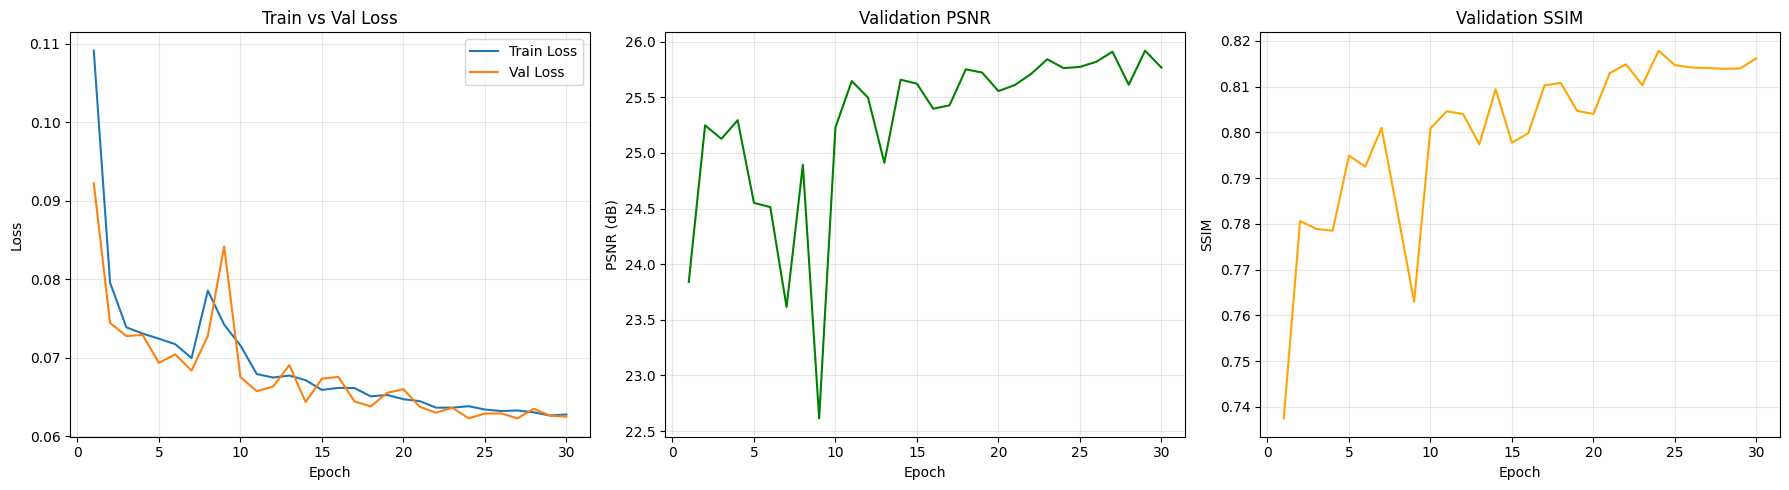

In [6]:
epochs_range = history["epoch"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Val Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["val_psnr"], color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("Validation PSNR")
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["val_ssim"], color="orange")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("SSIM")
axes[2].set_title("Validation SSIM")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Worst validation samples (error, val_index): [(0.23443613946437836, 124), (0.10620132833719254, 277), (0.09324797242879868, 59)]


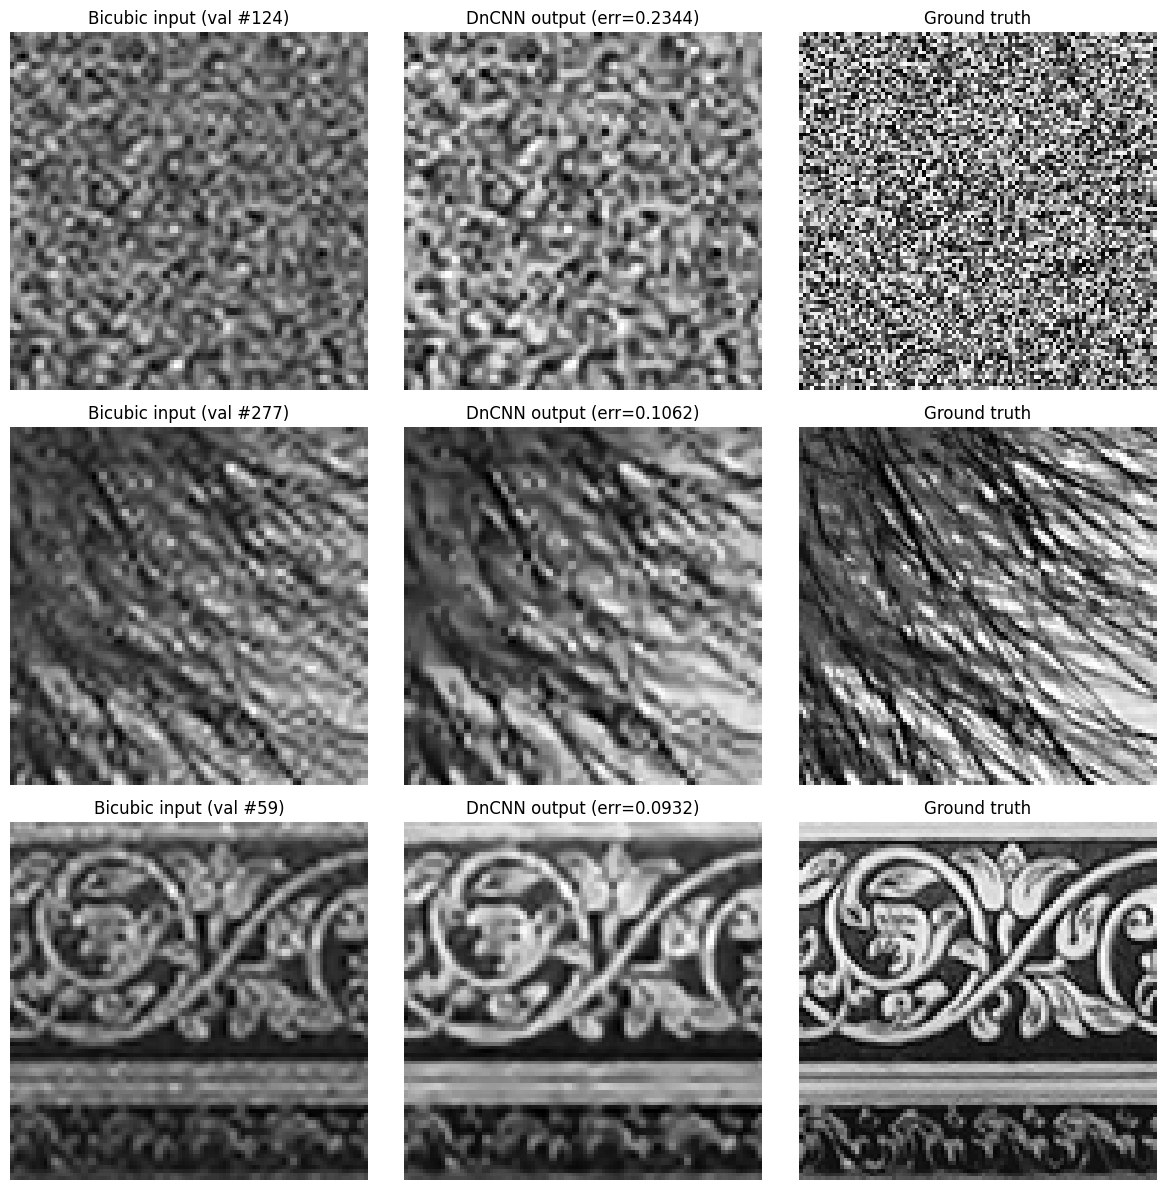

In [7]:
import heapq

model.eval()

per_image_error = []  # (error, val_index) pairs — cheap to keep, we refetch images after ranking
global_idx = 0

with torch.no_grad():
    for deg, gt in val_loader:
        deg, gt = deg.to(device), gt.to(device)
        pred = model(deg).clamp(0, 1)

        # Per-image error, not batch-averaged — mean absolute error per sample.
        # Swap to MSE if you'd rather rank by squared error (more sensitive to outlier pixels).
        batch_errors = torch.mean(torch.abs(pred - gt), dim=[1, 2, 3])  # shape (batch,)

        for i in range(deg.shape[0]):
            per_image_error.append((batch_errors[i].item(), global_idx))
            global_idx += 1

# Top 3 worst (highest error)
worst = heapq.nlargest(3, per_image_error, key=lambda x: x[0])
print("Worst validation samples (error, val_index):", worst)

# Refetch those specific samples from val_ds by index and run inference again
fig, axes = plt.subplots(len(worst), 3, figsize=(12, 4 * len(worst)))
if len(worst) == 1:
    axes = axes.reshape(1, 3)

with torch.no_grad():
    for row, (err, idx) in enumerate(worst):
        deg, gt = val_ds[idx]
        deg_b = deg.unsqueeze(0).to(device)
        gt_b  = gt.unsqueeze(0).to(device)
        pred_b = model(deg_b).clamp(0, 1)

        axes[row, 0].imshow(deg[0].cpu(), cmap="gray")
        axes[row, 0].set_title(f"Bicubic input (val #{idx})")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(pred_b[0, 0].cpu(), cmap="gray")
        axes[row, 1].set_title(f"DnCNN output (err={err:.4f})")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(gt[0].cpu(), cmap="gray")
        axes[row, 2].set_title("Ground truth")
        axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
TEST_DEG_DIR = "data/Test_NoisyLR/NoisyLR"

class TestOnlyDataset(Dataset):
    """No GT available — just loads and bicubic-upsamples degraded images for inference."""
    def __init__(self, deg_dir):
        self.deg_paths = sorted(glob.glob(os.path.join(deg_dir, "*.npy")))

    def __len__(self):
        return len(self.deg_paths)

    def __getitem__(self, idx):
        path = self.deg_paths[idx]
        arr = np.load(path).astype(np.float32)
        if arr.ndim == 3:
            arr = arr.squeeze()

        # Upsample 2x (matches training: 256->512 or 128->256).
        # Adjust target_h/target_w if your actual scale factor differs.
        h, w = arr.shape
        target_h, target_w = h * 2, w * 2

        deg_t = torch.from_numpy(arr).float().unsqueeze(0).unsqueeze(0)
        deg_up = F.interpolate(
            deg_t, size=(target_h, target_w), mode="bicubic", align_corners=False
        ).squeeze(0).squeeze(0).numpy()

        deg_out = torch.from_numpy(deg_up.copy()).unsqueeze(0).float()
        return deg_out, os.path.basename(path)  # return filename too, useful for tracking which is which


test_dataset = TestOnlyDataset(TEST_DEG_DIR)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

print(f"Test images: {len(test_dataset)}")

Test images: 400


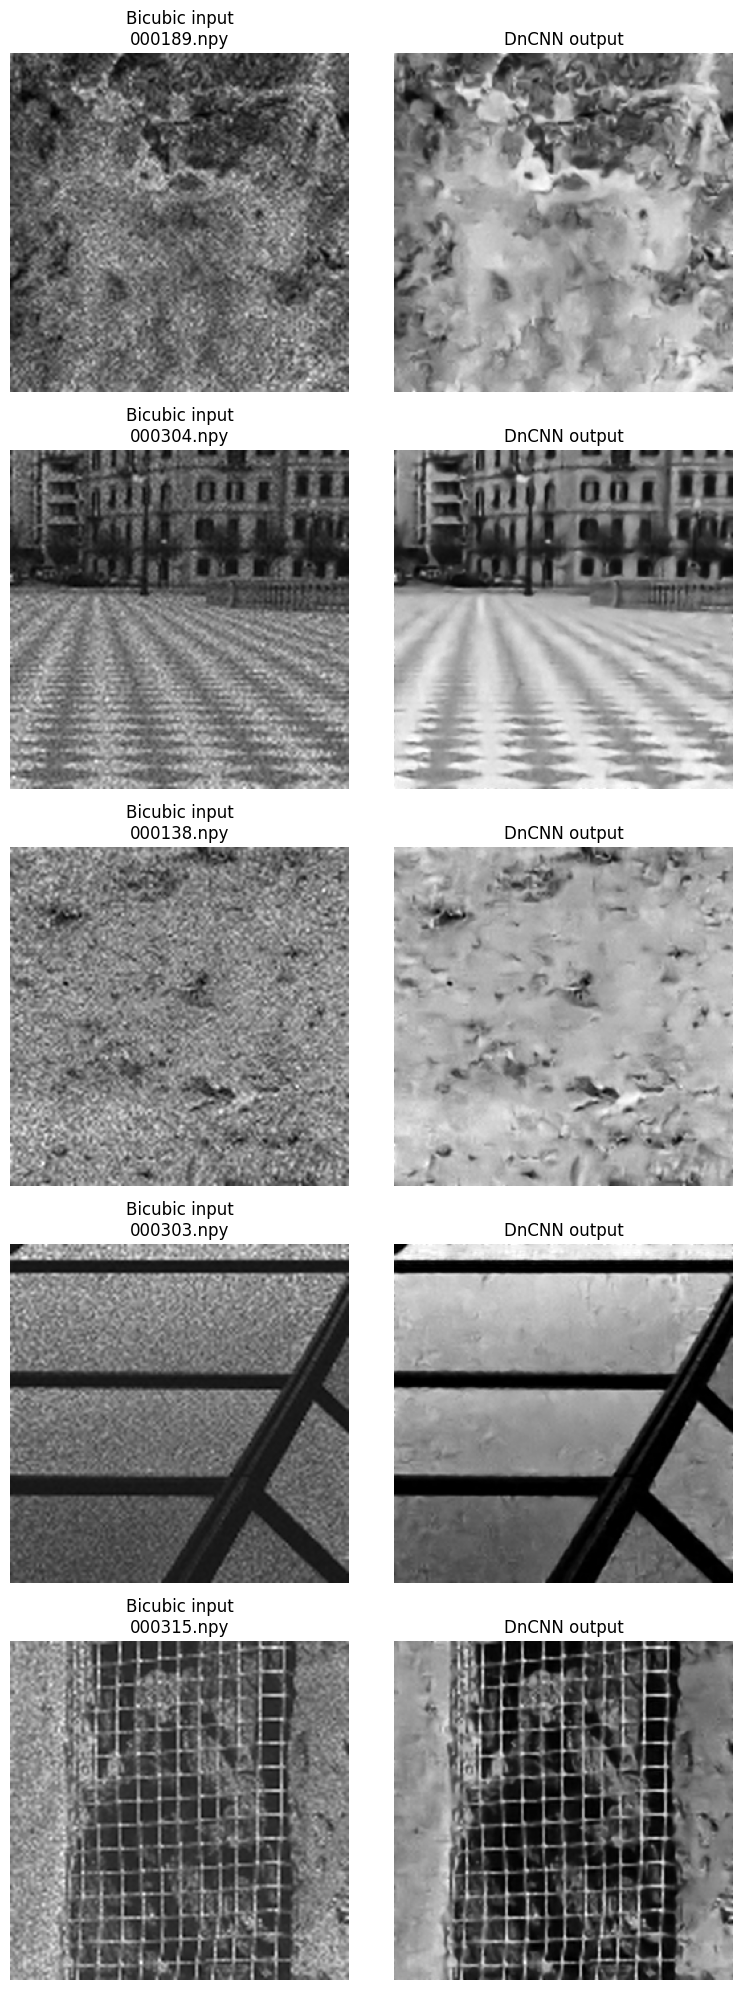

In [9]:
model.eval()

n_show = min(5, len(test_dataset))
random_indices = random.sample(range(len(test_dataset)), n_show)

fig, axes = plt.subplots(n_show, 2, figsize=(8, 4 * n_show))
if n_show == 1:
    axes = axes.reshape(1, 2)

with torch.no_grad():
    for row, idx in enumerate(random_indices):
        deg, fname = test_dataset[idx]
        deg_b = deg.unsqueeze(0).to(device)
        pred = model(deg_b).clamp(0, 1)

        axes[row, 0].imshow(deg[0].cpu(), cmap="gray")
        axes[row, 0].set_title(f"Bicubic input\n{fname}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(pred[0, 0].cpu(), cmap="gray")
        axes[row, 1].set_title("DnCNN output")
        axes[row, 1].axis("off")

plt.tight_layout()
plt.show()